In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [25]:
df = pd.read_csv("Flight_Delay_Prediction_Dataset_Raw.csv")

print("Dataset loaded successfully")
print("Rows:", df.shape[0], "Columns:", df.shape[1])

Dataset loaded successfully
Rows: 65000 Columns: 15


In [26]:
# Check unique values

for col in ["Airline", "Weather", "Aircraft_Type", "Holiday", "Delay_Status"]:
    print(col, ":", df[col].unique())

Airline : ['INDIGO' 'IndiGo' 'SpiceJet' 'Akasa Air' 'indigo' 'Air India' 'SPICEJET'
 'air india' 'Vistara' nan 'indigo ' 'INDIGO ' 'air india ' 'IndiGo '
 'Vistara ' 'Air India ' 'SpiceJet ' 'Akasa Air ' 'SPICEJET ' 'None ']
Weather : ['clear' 'CLEAR' 'Rain' 'Storm' 'Clear' 'Cloudy' 'Fog' nan]
Aircraft_Type : ['B737' 'A321' 'B787' 'ATR72' nan 'A320']
Holiday : [' yes' 'NO' 'No' 'Yes']
Delay_Status : [1 0]


In [27]:
# Check duplicates and target variable

print("Duplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
print(df["Delay_Status"].value_counts())
# Check numerical data

df.describe()

Duplicate rows: 1271

Target distribution:
Delay_Status
1    44403
0    20597
Name: count, dtype: int64


,Departure_Hour,Temperature_C,Wind_Speed_kmph,Distance_km,Departure_Delay_Min,Delay_Status,Flight_Number
count,65000.000000,61780.000000,61767.000000,61768.00000,65000.000000,65000.000000,65000.000000
mean,11.514538,26.301878,33.187624,1348.20033,26.317062,0.683123,5498.126831
std,6.920858,10.007594,17.375140,664.77519,18.985352,0.465263,2597.534285
min,0.000000,10.000000,5.000000,200.00000,0.000000,0.000000,1000.000000
25%,6.000000,18.000000,19.000000,770.00000,11.000000,0.000000,3260.000000
50%,12.000000,26.000000,33.000000,1352.00000,24.000000,1.000000,5500.000000
75%,18.000000,34.000000,47.000000,1925.00000,39.000000,1.000000,7755.000000
max,23.000000,58.000000,99.000000,2500.00000,98.000000,1.000000,9999.000000


In [28]:
# Remove duplicate rows

duplicates = df.duplicated().sum()
df = df.drop_duplicates().copy()

print("Duplicate rows removed:", duplicates)
print("Rows after removing duplicates:", df.shape[0])

Duplicate rows removed: 1271
Rows after removing duplicates: 63729


In [29]:
# Impute missing values

num_imputer = SimpleImputer(strategy="median")
df[["Temperature_C", "Wind_Speed_kmph", "Distance_km"]] = num_imputer.fit_transform(
    df[["Temperature_C", "Wind_Speed_kmph", "Distance_km"]]
)

cat_imputer = SimpleImputer(strategy="most_frequent")
df[["Airline", "Weather", "Aircraft_Type"]] = cat_imputer.fit_transform(
    df[["Airline", "Weather", "Aircraft_Type"]]
)

print("Missing values imputed")

Missing values imputed


In [30]:
# Check missing values after imputation

print(df.isnull().sum())

Flight_ID              0
Airline                0
Origin                 0
Destination            0
Date                   0
Departure_Hour         0
Weather                0
Temperature_C          0
Wind_Speed_kmph        0
Distance_km            0
Aircraft_Type          0
Holiday                0
Departure_Delay_Min    0
Delay_Status           0
Flight_Number          0
dtype: int64


In [31]:
# Remove outliers

q1 = df["Wind_Speed_kmph"].quantile(0.25)
q3 = df["Wind_Speed_kmph"].quantile(0.75)
iqr = q3 - q1

df = df[
    (df["Wind_Speed_kmph"] >= q1 - 1.5 * iqr) &
    (df["Wind_Speed_kmph"] <= q3 + 1.5 * iqr)
].copy()

print("Outliers removed")
print("Rows after outlier removal:", df.shape[0])

Outliers removed
Rows after outlier removal: 63094


In [32]:
# Encode categorical columns

le = LabelEncoder()
for col in ["Airline", "Origin", "Destination", "Weather", "Aircraft_Type", "Holiday"]:
    df[col] = le.fit_transform(df[col])

print("Categorical columns encoded")

Categorical columns encoded


In [33]:
# Remove unnecessary columns

df = df.drop(["Flight_ID", "Date"], axis=1)
print("Dataset shape:", df.shape)


Dataset shape: (63094, 13)


In [34]:
# Remove leakage and identifier features

df = df.drop(["Departure_Delay_Min", "Flight_Number"], axis=1)

print("Columns:", df.columns.tolist())
df.head()

Columns: ['Airline', 'Origin', 'Destination', 'Departure_Hour', 'Weather', 'Temperature_C', 'Wind_Speed_kmph', 'Distance_km', 'Aircraft_Type', 'Holiday', 'Delay_Status']


,Airline,Origin,Destination,Departure_Hour,Weather,Temperature_C,Wind_Speed_kmph,Distance_km,Aircraft_Type,Holiday,Delay_Status
0,4,2,4,13,6,26.0,33.0,1777.0,3,0,1
1,6,0,7,19,0,19.0,12.0,306.0,1,0,1
2,11,6,4,12,4,10.0,23.0,1492.0,4,1,1
3,2,0,1,21,6,24.0,57.0,495.0,2,0,1
4,17,4,1,21,6,24.0,38.0,2392.0,2,1,0


In [35]:
# Separate features and target

X = df.drop("Delay_Status", axis=1)
y = df["Delay_Status"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (63094, 10)
Target shape: (63094,)


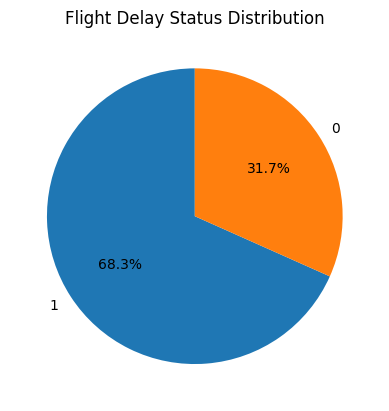

In [36]:

# Target Class Distribution

df["Delay_Status"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", startangle=90
)
plt.title("Flight Delay Status Distribution")
plt.ylabel("")
plt.show()

In [37]:
# Check Class Balance

print(df["Delay_Status"].value_counts())
print(df["Delay_Status"].value_counts(normalize=True).mul(100).round(2))

Delay_Status
1    43109
0    19985
Name: count, dtype: int64
Delay_Status
1    68.33
0    31.67
Name: proportion, dtype: float64


In [38]:
# Check outliers

for col in ["Temperature_C", "Wind_Speed_kmph", "Distance_km"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    print(col, "Outliers:", ((df[col] < q1-1.5*(q3-q1)) | (df[col] > q3+1.5*(q3-q1))).sum())

Temperature_C Outliers: 0
Wind_Speed_kmph Outliers: 0
Distance_km Outliers: 0


In [39]:
# Split data into training and testing data

X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("70-30:", X_train_70.shape, X_test_70.shape)
print("80-20:", X_train_80.shape, X_test_80.shape)

70-30: (44165, 10) (18929, 10)
80-20: (50475, 10) (12619, 10)


In [40]:

# Scale the features

scaler_70 = StandardScaler()
X_train_70 = scaler_70.fit_transform(X_train_70)
X_test_70 = scaler_70.transform(X_test_70)

scaler_80 = StandardScaler()
X_train_80 = scaler_80.fit_transform(X_train_80)
X_test_80 = scaler_80.transform(X_test_80)

print("Feature scaling completed")

Feature scaling completed


In [41]:
# Logistic Regression

lr_70 = LogisticRegression(max_iter=10000)
lr_70.fit(X_train_70, y_train_70)
y_pred_lr_70 = lr_70.predict(X_test_70)

lr_80 = LogisticRegression(max_iter=10000)
lr_80.fit(X_train_80, y_train_80)
y_pred_lr_80 = lr_80.predict(X_test_80)

print("70-30 Accuracy:", accuracy_score(y_test_70, y_pred_lr_70))
print(classification_report(y_test_70, y_pred_lr_70))

print("80-20 Accuracy:", accuracy_score(y_test_80, y_pred_lr_80))
print(classification_report(y_test_80, y_pred_lr_80))

70-30 Accuracy: 0.7363833271699509
              precision    recall  f1-score   support

           0       0.66      0.34      0.45      5982
           1       0.75      0.92      0.83     12947

    accuracy                           0.74     18929
   macro avg       0.71      0.63      0.64     18929
weighted avg       0.72      0.74      0.71     18929

80-20 Accuracy: 0.7357952294159601
              precision    recall  f1-score   support

           0       0.64      0.33      0.44      3921
           1       0.75      0.92      0.83      8698

    accuracy                           0.74     12619
   macro avg       0.70      0.63      0.63     12619
weighted avg       0.72      0.74      0.71     12619



In [42]:
# KNN

knn_70 = KNeighborsClassifier(n_neighbors=5)
knn_70.fit(X_train_70, y_train_70)
y_pred_knn_70 = knn_70.predict(X_test_70)

knn_80 = KNeighborsClassifier(n_neighbors=5)
knn_80.fit(X_train_80, y_train_80)
y_pred_knn_80 = knn_80.predict(X_test_80)

print("70-30 Accuracy:", accuracy_score(y_test_70, y_pred_knn_70))
print(classification_report(y_test_70, y_pred_knn_70))

print("80-20 Accuracy:", accuracy_score(y_test_80, y_pred_knn_80))
print(classification_report(y_test_80, y_pred_knn_80))

70-30 Accuracy: 0.7681335516931692
              precision    recall  f1-score   support

           0       0.67      0.53      0.59      5982
           1       0.80      0.88      0.84     12947

    accuracy                           0.77     18929
   macro avg       0.73      0.70      0.72     18929
weighted avg       0.76      0.77      0.76     18929

80-20 Accuracy: 0.7701085664474205
              precision    recall  f1-score   support

           0       0.66      0.53      0.59      3921
           1       0.81      0.88      0.84      8698

    accuracy                           0.77     12619
   macro avg       0.73      0.70      0.72     12619
weighted avg       0.76      0.77      0.76     12619



In [43]:
# Decision Tree

dt_70 = DecisionTreeClassifier(random_state=42)
dt_70.fit(X_train_70, y_train_70)
y_pred_dt_70 = dt_70.predict(X_test_70)

dt_80 = DecisionTreeClassifier(random_state=42)
dt_80.fit(X_train_80, y_train_80)
y_pred_dt_80 = dt_80.predict(X_test_80)

print("70-30 Accuracy:", accuracy_score(y_test_70, y_pred_dt_70))
print(classification_report(y_test_70, y_pred_dt_70))

print("80-20 Accuracy:", accuracy_score(y_test_80, y_pred_dt_80))
print(classification_report(y_test_80, y_pred_dt_80))

70-30 Accuracy: 0.8025780548364942
              precision    recall  f1-score   support

           0       0.69      0.69      0.69      5982
           1       0.86      0.86      0.86     12947

    accuracy                           0.80     18929
   macro avg       0.77      0.77      0.77     18929
weighted avg       0.80      0.80      0.80     18929

80-20 Accuracy: 0.795704889452413
              precision    recall  f1-score   support

           0       0.67      0.68      0.67      3921
           1       0.85      0.85      0.85      8698

    accuracy                           0.80     12619
   macro avg       0.76      0.76      0.76     12619
weighted avg       0.80      0.80      0.80     12619



In [44]:
# Naive Bayes

nb_70 = GaussianNB()
nb_70.fit(X_train_70, y_train_70)
y_pred_nb_70 = nb_70.predict(X_test_70)

nb_80 = GaussianNB()
nb_80.fit(X_train_80, y_train_80)
y_pred_nb_80 = nb_80.predict(X_test_80)

print("70-30 Accuracy:", accuracy_score(y_test_70, y_pred_nb_70))
print(classification_report(y_test_70, y_pred_nb_70))

print("80-20 Accuracy:", accuracy_score(y_test_80, y_pred_nb_80))
print(classification_report(y_test_80, y_pred_nb_80))

70-30 Accuracy: 0.7610544666913202
              precision    recall  f1-score   support

           0       0.77      0.35      0.48      5982
           1       0.76      0.95      0.84     12947

    accuracy                           0.76     18929
   macro avg       0.76      0.65      0.66     18929
weighted avg       0.76      0.76      0.73     18929

80-20 Accuracy: 0.7617085347491878
              precision    recall  f1-score   support

           0       0.76      0.35      0.47      3921
           1       0.76      0.95      0.85      8698

    accuracy                           0.76     12619
   macro avg       0.76      0.65      0.66     12619
weighted avg       0.76      0.76      0.73     12619



In [45]:
# Random Forest

rf_70 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_70.fit(X_train_70, y_train_70)
y_pred_rf_70 = rf_70.predict(X_test_70)

rf_80 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_80.fit(X_train_80, y_train_80)
y_pred_rf_80 = rf_80.predict(X_test_80)

print("70-30 Accuracy:", accuracy_score(y_test_70, y_pred_rf_70))
print(classification_report(y_test_70, y_pred_rf_70))

print("80-20 Accuracy:", accuracy_score(y_test_80, y_pred_rf_80))
print(classification_report(y_test_80, y_pred_rf_80))

70-30 Accuracy: 0.8491732262665751
              precision    recall  f1-score   support

           0       0.76      0.76      0.76      5982
           1       0.89      0.89      0.89     12947

    accuracy                           0.85     18929
   macro avg       0.83      0.83      0.83     18929
weighted avg       0.85      0.85      0.85     18929

80-20 Accuracy: 0.8495126396703384
              precision    recall  f1-score   support

           0       0.76      0.76      0.76      3921
           1       0.89      0.89      0.89      8698

    accuracy                           0.85     12619
   macro avg       0.82      0.82      0.82     12619
weighted avg       0.85      0.85      0.85     12619



In [46]:
# Linear SVM

svm_80 = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42,
    max_iter=2000
)

svm_80.fit(X_train_80, y_train_80)
y_pred_svm_80 = svm_80.predict(X_test_80)

print("SVM Accuracy:", round(accuracy_score(y_test_80, y_pred_svm_80), 4))
print(classification_report(y_test_80, y_pred_svm_80))

SVM Accuracy: 0.658
              precision    recall  f1-score   support

           0       0.47      0.67      0.55      3921
           1       0.82      0.65      0.72      8698

    accuracy                           0.66     12619
   macro avg       0.64      0.66      0.64     12619
weighted avg       0.71      0.66      0.67     12619



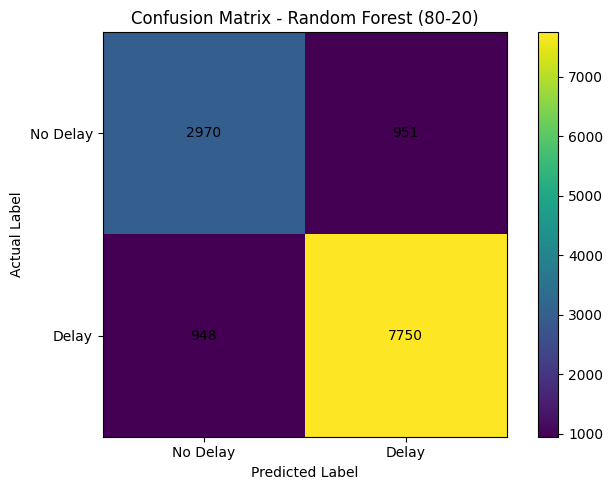

In [47]:
# Confusion Matrix Visualization

cm = confusion_matrix(y_test_80, y_pred_rf_80)

plt.figure(figsize=(7, 5))

plt.imshow(cm, interpolation="nearest")

plt.title("Confusion Matrix - Random Forest (80-20)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["No Delay", "Delay"])
plt.yticks([0, 1], ["No Delay", "Delay"])

# Display values inside the matrix

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.colorbar()

plt.tight_layout()
plt.show()

In [48]:
# Compare model accuracies

results = {
    "Logistic Regression": [
        accuracy_score(y_test_70, y_pred_lr_70),
        accuracy_score(y_test_80, y_pred_lr_80)    ],
    "KNN": [
        accuracy_score(y_test_70, y_pred_knn_70),
        accuracy_score(y_test_80, y_pred_knn_80)    ],
    "Decision Tree": [
        accuracy_score(y_test_70, y_pred_dt_70),
        accuracy_score(y_test_80, y_pred_dt_80)    ],
    "Naive Bayes": [
        accuracy_score(y_test_70, y_pred_nb_70),
        accuracy_score(y_test_80, y_pred_nb_80)    ],
    "Random Forest": [
        accuracy_score(y_test_70, y_pred_rf_70),
        accuracy_score(y_test_80, y_pred_rf_80)    ],
   "SVM": [
    None,
    accuracy_score(y_test_80, y_pred_svm_80)
]
}

comparison = pd.DataFrame(results, index=["70-30", "80-20"]).T
comparison.columns = ["70-30 Accuracy", "80-20 Accuracy"]

print(comparison)

                     70-30 Accuracy  80-20 Accuracy
Logistic Regression        0.736383        0.735795
KNN                        0.768134        0.770109
Decision Tree              0.802578        0.795705
Naive Bayes                0.761054        0.761709
Random Forest              0.849173        0.849513
SVM                             NaN        0.657976


In [51]:
# Model Training Time

models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": LinearSVC(class_weight="balanced", max_iter=2000, random_state=42)
}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_80, y_train_80)
    print(name, "Time:", round(time.time() - start, 3), "sec")

Logistic Regression Time: 0.054 sec
KNN Time: 0.157 sec
Decision Tree Time: 0.491 sec
Naive Bayes Time: 0.022 sec
Random Forest Time: 9.627 sec
SVM Time: 0.038 sec


In [53]:
# 5-Fold Cross Validation

models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": LinearSVC(
        C=1.0,
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    )
}

for name, model in models.items():
    scores = cross_val_score(model, X_train_80, y_train_80, cv=5)
    print(name, "Mean:", round(scores.mean(), 4),
          "Std:", round(scores.std(), 4))

Logistic Regression Mean: 0.7315 Std: 0.0024
KNN Mean: 0.767 Std: 0.0042
Decision Tree Mean: 0.796 Std: 0.0045
Naive Bayes Mean: 0.7599 Std: 0.0024
Random Forest Mean: 0.8471 Std: 0.0034
SVM Mean: 0.6628 Std: 0.0049


In [55]:
# Grid Search for all models

param_grids = {
    "Logistic Regression": (
        LogisticRegression(max_iter=10000),
        {"C": [0.1, 1, 10]}
    ),

    "KNN": (
        KNeighborsClassifier(),
        {"n_neighbors": [3, 5, 7]}
    ),

    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {"max_depth": [10, 20, None]}
    ),

    "Naive Bayes": (
        GaussianNB(),
        {"var_smoothing": [1e-9, 1e-8, 1e-7]}
    ),

    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {"n_estimators": [50, 100], "max_depth": [10, 20]}
    ),

    "SVM": (
        LinearSVC(class_weight="balanced", random_state=42),
        {"C": [0.1, 1, 10]}
    )
}

best_models = {}

for name, (model, params) in param_grids.items():

    grid = GridSearchCV(
        model,
        params,
        cv=5,
        scoring="accuracy",
        n_jobs=1
    )

    grid.fit(X_train_80, y_train_80)

    best_models[name] = grid.best_estimator_

    print(name)
    print("Best Parameters:", grid.best_params_)
    print("Best CV Accuracy:", round(grid.best_score_, 4))
    print()

Logistic Regression
Best Parameters: {'C': 0.1}
Best CV Accuracy: 0.7316

KNN
Best Parameters: {'n_neighbors': 7}
Best CV Accuracy: 0.7723

Decision Tree
Best Parameters: {'max_depth': 10}
Best CV Accuracy: 0.8451

Naive Bayes
Best Parameters: {'var_smoothing': 1e-09}
Best CV Accuracy: 0.7599

Random Forest
Best Parameters: {'max_depth': 20, 'n_estimators': 100}
Best CV Accuracy: 0.8482

SVM
Best Parameters: {'C': 0.1}
Best CV Accuracy: 0.6628



In [58]:
  # Tuned Model Results

  tuned_results = {}

  for name, model in best_models.items():
      y_pred = model.predict(X_test_80)
      accuracy = accuracy_score(y_test_80, y_pred)
      tuned_results[name] = accuracy
      print(name, "Accuracy:", round(accuracy, 4))

Logistic Regression Accuracy: 0.736
KNN Accuracy: 0.7747
Decision Tree Accuracy: 0.8447
Naive Bayes Accuracy: 0.7617
Random Forest Accuracy: 0.8476
SVM Accuracy: 0.6579


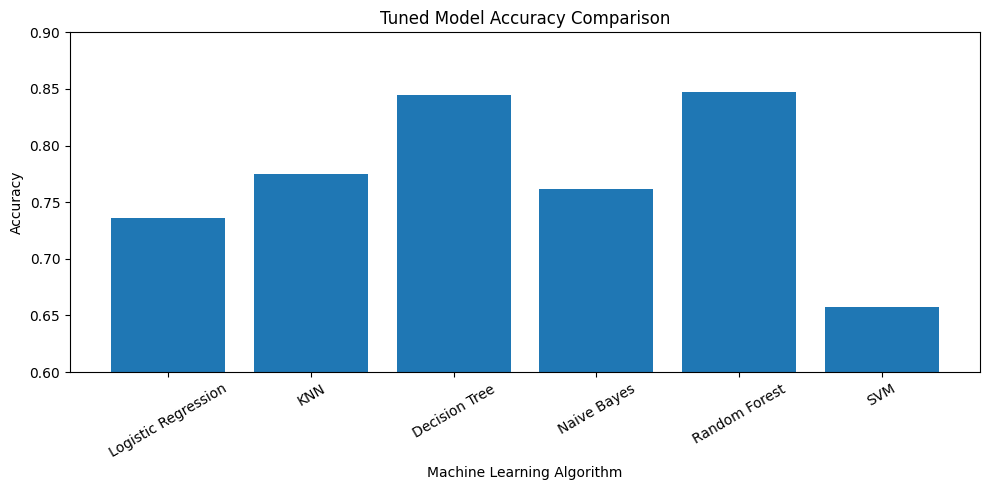

In [59]:
# Tuned Model Accuracy Comparison

models_name = list(tuned_results.keys())
accuracies = list(tuned_results.values())

plt.figure(figsize=(10, 5))
plt.bar(models_name, accuracies)

plt.xlabel("Machine Learning Algorithm")
plt.ylabel("Accuracy")
plt.title("Tuned Model Accuracy Comparison")

plt.xticks(rotation=30)
plt.ylim(0.60, 0.90)

plt.tight_layout()
plt.show()

In [60]:
# Confusion Matrix for the Best Model

best_name = max(tuned_results, key=tuned_results.get)
best_model = best_models[best_name]
y_pred_best = best_model.predict(X_test_80)

cm = confusion_matrix(y_test_80, y_pred_best)

print("Best Model:", best_name)
print("Confusion Matrix:")
print(cm)

Best Model: Random Forest
Confusion Matrix:
[[2942  979]
 [ 944 7754]]


In [61]:
# Classification Report for the Best Model

print("Best Model:", best_name)
print(classification_report(y_test_80, y_pred_best))

Best Model: Random Forest
              precision    recall  f1-score   support

           0       0.76      0.75      0.75      3921
           1       0.89      0.89      0.89      8698

    accuracy                           0.85     12619
   macro avg       0.82      0.82      0.82     12619
weighted avg       0.85      0.85      0.85     12619



In [62]:
# Final Model Comparison

final_results = pd.DataFrame({
    "Model": list(tuned_results.keys()),
    "Accuracy": list(tuned_results.values())
}).sort_values("Accuracy", ascending=False)

print(final_results)

                 Model  Accuracy
4        Random Forest  0.847611
2        Decision Tree  0.844679
1                  KNN  0.774705
3          Naive Bayes  0.761709
0  Logistic Regression  0.735954
5                  SVM  0.657897


In [67]:
# Best Model Result

print("Best Model:", best_name)
print("Train-Test Split: 80-20")
print("Accuracy:", round(tuned_results[best_name], 4))

Best Model: Random Forest
Train-Test Split: 80-20
Accuracy: 0.8476


In [68]:
# Final Model Comparison

final_results = pd.DataFrame({
    "Model": list(tuned_results.keys()),
    "Accuracy": list(tuned_results.values())
}).sort_values("Accuracy", ascending=False)

print(final_results)

                 Model  Accuracy
4        Random Forest  0.847611
2        Decision Tree  0.844679
1                  KNN  0.774705
3          Naive Bayes  0.761709
0  Logistic Regression  0.735954
5                  SVM  0.657897


In [69]:
# Final Best Model

print("Best Model:", best_name)
print("Accuracy:", round(tuned_results[best_name], 4))

Best Model: Random Forest
Accuracy: 0.8476


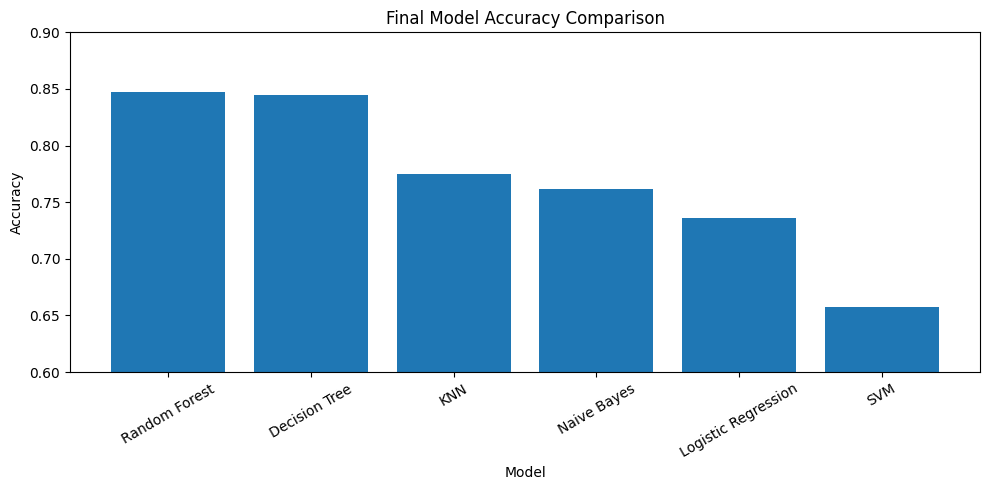

In [70]:
# Final Model Accuracy Graph

plt.figure(figsize=(10, 5))

plt.bar(final_results["Model"], final_results["Accuracy"])

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Final Model Accuracy Comparison")

plt.xticks(rotation=30)
plt.ylim(0.60, 0.90)

plt.tight_layout()
plt.show()

In [ ]:
# Changes in milestone
# Linear in svm
# outlir handling
# all algo use cross fold
# use mode in categoical
# gredy search use in all algo